In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from sklearn.decomposition import PCA
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries loaded ✓")

All libraries loaded ✓


In [2]:
# ── File paths ────────────────────────────────────────────────────
SPEC_PATH = "data/diesel_spec.csv"
PROP_PATH = "data/diesel_prop.csv"

# ── Load spectra (X) ──────────────────────────────────────────────
X_raw = pd.read_csv(SPEC_PATH, header=None, skiprows=10)
X_raw = X_raw.dropna(how='all')
X_raw = X_raw.set_index(1)
X_raw = X_raw.drop(columns=[0])
X_raw.index.name = 'SampleID'
X_raw.index = X_raw.index.astype(str)

# Drop any trailing columns that are entirely NaN
X_raw = X_raw.dropna(axis=1, how='all')

# Get wavelengths from row 9, columns 2 onward
wav_row    = pd.read_csv(SPEC_PATH, header=None, skiprows=9, nrows=1)
wavelengths = wav_row.iloc[0, 2:].dropna().astype(float).values

# Trim both to the same length before assigning
n = min(len(wavelengths), X_raw.shape[1])
X_raw      = X_raw.iloc[:, :n]
wavelengths = wavelengths[:n]
X_raw.columns = wavelengths

# ── Load properties (Y) ───────────────────────────────────────────
Y_raw = pd.read_csv(PROP_PATH, header=None, skiprows=9)
Y_raw = Y_raw.dropna(how='all')
Y_raw = Y_raw.set_index(1)
Y_raw = Y_raw.drop(columns=[0])
Y_raw.index.name = 'SampleID'
Y_raw.index = Y_raw.index.astype(str)

# Get property names from row 8
prop_row      = pd.read_csv(PROP_PATH, header=None, skiprows=8, nrows=1)
prop_names_raw = prop_row.iloc[0, 2:].dropna().values
Y_raw          = Y_raw.iloc[:, :len(prop_names_raw)]
Y_raw.columns  = prop_names_raw
Y_raw          = Y_raw.apply(pd.to_numeric, errors='coerce')
Y_raw          = Y_raw.dropna(how='all')

# ── Align on common sample IDs ────────────────────────────────────
common = X_raw.index.intersection(Y_raw.index)
X_raw  = X_raw.loc[common]
Y_raw  = Y_raw.loc[common]

# ── Report ────────────────────────────────────────────────────────
print("=" * 48)
print(f"  Spectra  (X) : {X_raw.shape[0]} samples × {X_raw.shape[1]} wavelengths")
print(f"  Wavelengths  : {wavelengths[0]:.0f} – {wavelengths[-1]:.0f} nm")
print(f"  Properties(Y): {Y_raw.shape[0]} samples × {Y_raw.shape[1]} properties")
print(f"  Properties   : {list(Y_raw.columns)}")
print(f"  Common samples: {len(common)}")
print("=" * 48)

# ── Convert to numpy ──────────────────────────────────────────────
X          = X_raw.values.astype(float)
Y          = Y_raw.values.astype(float)
prop_names = list(Y_raw.columns)

print(f"\n  X array : {X.shape}")
print(f"  Y array : {Y.shape}")
print(f"\nReady for preprocessing ✓")

  Spectra  (X) : 784 samples × 401 wavelengths
  Wavelengths  : 750 – 1550 nm
  Properties(Y): 784 samples × 7 properties
  Properties   : ['BP50', 'CN', 'D4052', 'FLASH', 'FREEZE', 'TOTAL', 'VISC']
  Common samples: 784

  X array : (784, 401)
  Y array : (784, 7)

Ready for preprocessing ✓


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SHARED PREAMBLE  —  Run once, variables reused by all cells    ║
# ║  Requires: X, X_raw, Y_raw, wavelengths, prop_names            ║
# ╚══════════════════════════════════════════════════════════════════╝

os.makedirs("reports/figures", exist_ok=True)

PROP_UNITS = {'BP50':'°C','CN':'—','D4052':'g/mL','FLASH':'°C','FREEZE':'°C','TOTAL':'% vol','VISC':'mm²/s'}
NIR_BANDS  = [(980,'O-H'),(1190,'C-H'),(1400,'O-H')]
PALETTE    = dict(main='#2c7bb6', fill='#abd9e9', warn='#d7191c', neutral='#bdbdbd')
SAVE_KW    = dict(dpi=150, bbox_inches='tight')

# ── PCA (computed once, reused in Cells 3 and 6) ─────────────────
A     = 10
X_sc  = StandardScaler().fit_transform(X)
pca   = PCA(n_components=20, random_state=42)
T     = pca.fit_transform(X_sc)
X_rec = pca.inverse_transform(T)
exp_var = pca.explained_variance_ratio_ * 100

# ── Hotelling T² ─────────────────────────────────────────────────
T_A     = T[:, :A]
cov_inv = np.linalg.inv(np.cov(T_A.T))
T2      = np.einsum('ni,ij,nj->n', T_A, cov_inv, T_A)
T2_lim  = stats.chi2.ppf(0.95, df=A)

# ── Q residuals (SPE) ────────────────────────────────────────────
Q     = np.sum((X_sc - X_rec) ** 2, axis=1)
ev    = pca.explained_variance_[A:]
th1, th2, th3 = ev.sum(), (ev**2).sum(), (ev**3).sum()
h0    = 1 - (2*th1*th3) / (3*th2**2)
Q_lim = th1 * (stats.norm.ppf(0.95) * np.sqrt(2*th2*h0**2)/th1
               + 1 + th2*h0*(h0-1)/th1**2)**(1/h0)

outliers_T2 = np.where(T2 > T2_lim)[0]
outliers_Q  = np.where(Q  > Q_lim)[0]
outliers    = np.union1d(outliers_T2, outliers_Q)
normal_mask = np.ones(len(T2), dtype=bool); normal_mask[outliers] = False

print(f"T² limit ({A} LVs, 95%): {T2_lim:.2f}  → {len(outliers_T2)} flagged")
print(f"Q  limit ({A} LVs, 95%): {Q_lim:.4f}  → {len(outliers_Q)} flagged")
print(f"Union: {len(outliers)} outlier samples")

# ── Correlation spectra (vectorized) ─────────────────────────────
def _pearson_spectra(X_v, y_v):
    Xc  = X_v - X_v.mean(axis=0)
    yc  = y_v - y_v.mean()
    num = (Xc * yc[:, None]).sum(axis=0)
    den = np.sqrt((Xc**2).sum(axis=0)) * np.sqrt((yc**2).sum())
    return num / den

corr_spectra = {
    p: _pearson_spectra(X[Y_raw[p].notna().values], Y_raw[p].dropna().values)
    for p in prop_names
}

ncols = 2
nrows = (len(prop_names) + 1) // ncols

print("Preamble ready ✓")

T² limit (10 LVs, 95%): 18.31  → 67 flagged
Q  limit (10 LVs, 95%): 1.5703  → 0 flagged
Union: 67 outlier samples
Preamble ready ✓


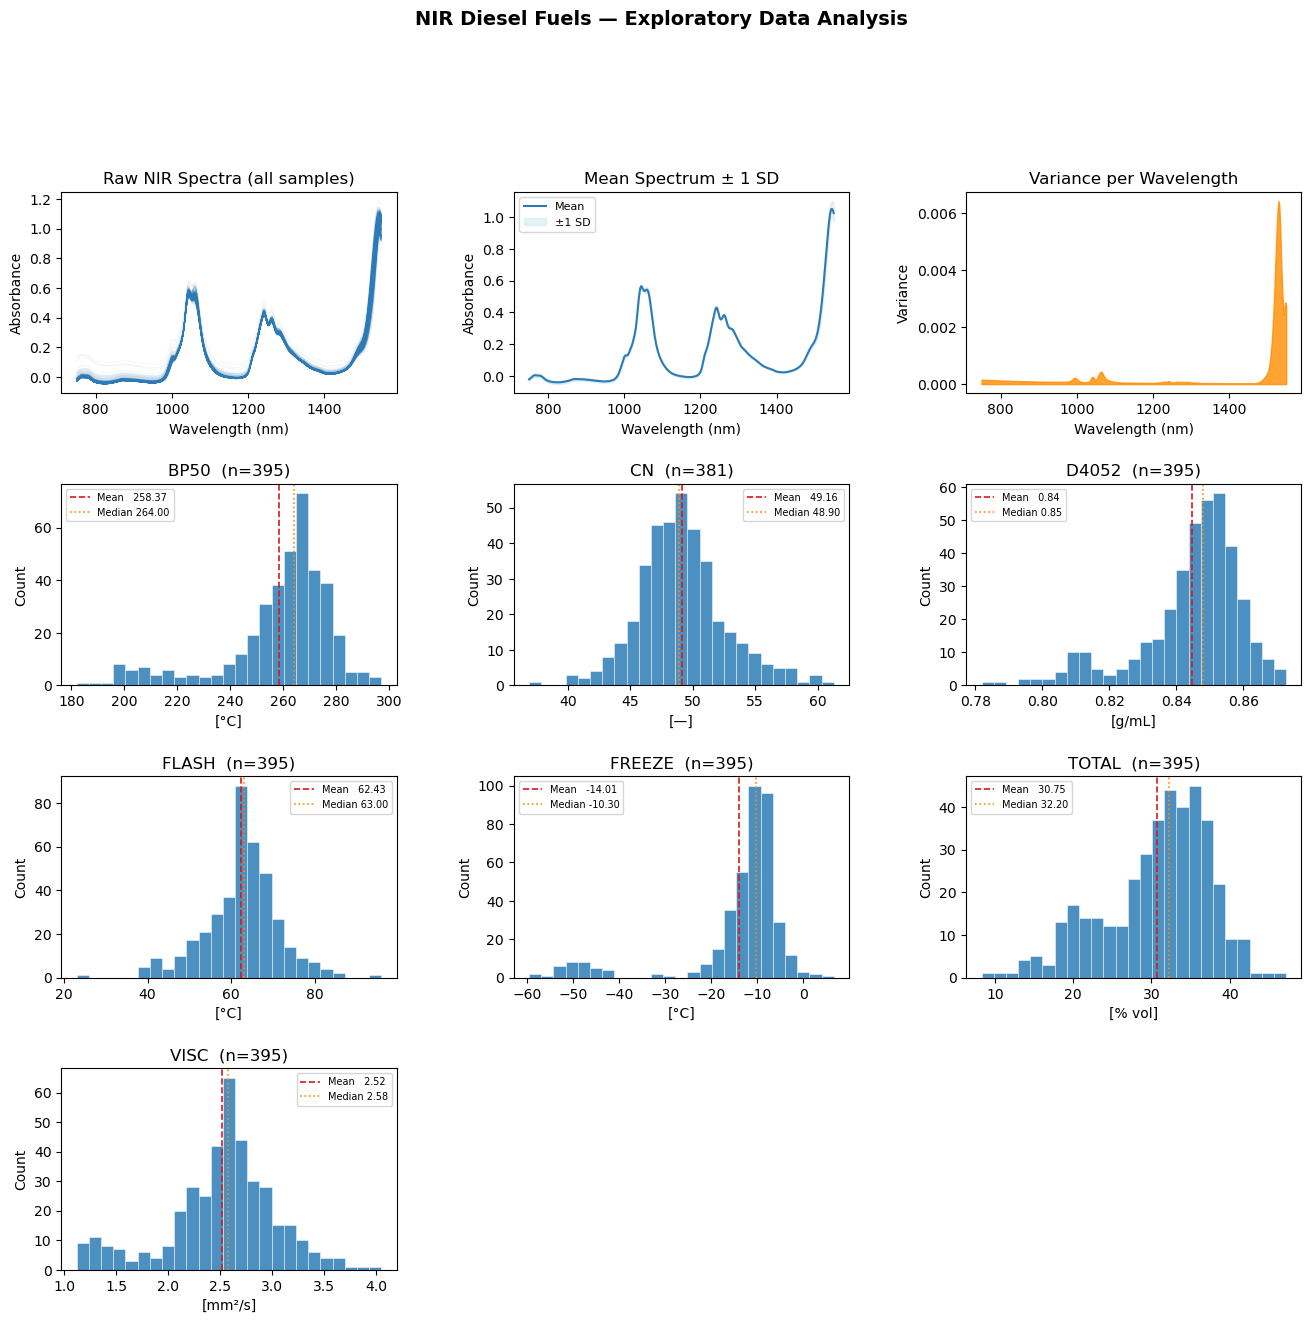

01_EDA.png saved ✓


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2  —  Raw Spectra + Property Distributions               ║
# ╚══════════════════════════════════════════════════════════════════╝
from matplotlib.gridspec import GridSpec

mean_spec = X.mean(axis=0)
std_spec  = X.std(axis=0)

fig = plt.figure(figsize=(16, 14))
fig.suptitle("NIR Diesel Fuels — Exploratory Data Analysis",
             fontsize=14, fontweight='bold', y=1.01)
gs = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# Spectra row
ax = fig.add_subplot(gs[0, 0])
ax.plot(wavelengths, X.T, alpha=0.08, lw=0.5, color=PALETTE['main'], rasterized=True)
ax.set(title="Raw NIR Spectra (all samples)", xlabel="Wavelength (nm)", ylabel="Absorbance")
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

ax = fig.add_subplot(gs[0, 1])
ax.plot(wavelengths, mean_spec, color=PALETTE['main'], lw=1.5, label='Mean')
ax.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec,
                alpha=0.3, color=PALETTE['fill'], label='±1 SD')
ax.set(title="Mean Spectrum ± 1 SD", xlabel="Wavelength (nm)", ylabel="Absorbance")
ax.legend(fontsize=8); ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

ax = fig.add_subplot(gs[0, 2])
ax.fill_between(wavelengths, X.var(axis=0), color='darkorange', alpha=0.8)
ax.set(title="Variance per Wavelength", xlabel="Wavelength (nm)", ylabel="Variance")
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

# Property histograms (7 props across rows 1–3)
for i, prop in enumerate(prop_names):
    row, col = divmod(i + 3, 3)
    ax   = fig.add_subplot(gs[row, col])
    vals = Y_raw[prop].dropna()
    ax.hist(vals, bins=25, color=PALETTE['main'], edgecolor='white', lw=0.4, alpha=0.85)
    ax.axvline(vals.mean(),   color=PALETTE['warn'], lw=1.2, ls='--', label=f'Mean   {vals.mean():.2f}')
    ax.axvline(vals.median(), color='darkorange',    lw=1.2, ls=':',  label=f'Median {vals.median():.2f}')
    ax.set(title=f"{prop}  (n={len(vals)})", xlabel=f"[{PROP_UNITS.get(prop,'')}]", ylabel="Count")
    ax.legend(fontsize=7)

for hide_col in [1, 2]:
    fig.add_subplot(gs[3, hide_col]).set_visible(False)

plt.savefig("reports/figures/01_EDA.png", **SAVE_KW)
plt.show(); print("01_EDA.png saved ✓")

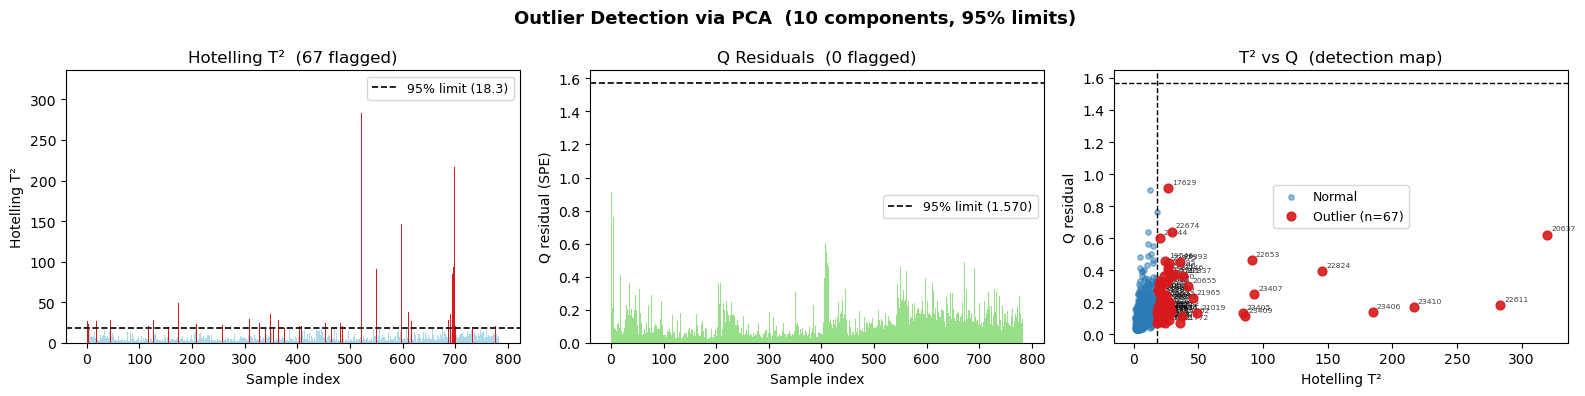

02_outliers.png saved ✓
Outlier IDs: ['17366', '17629', '19546', '20573', '20633', '20637', '20655', '20795', '20835', '20850', '20867', '20906', '20926', '20936', '20999', '21019', '21022', '21055', '21291', '21468', '21626', '21662', '21693', '21695', '21732', '21751', '21762', '21772', '21773', '21786', '21798', '21811', '21834', '21839', '21844', '21962', '21965', '22461', '22554', '22571', '22575', '22611', '22653', '22674', '22824', '22827', '22837', '22840', '22843', '22875', '22890', '22982', '23085', '23203', '23204', '23393', '23405', '23406', '23407', '23409', '23410', '23415', '23742', '23746', '23747', '24331', '24373']


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3  —  Outlier Detection (T² & Q)                         ║
# ╚══════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Outlier Detection via PCA  ({A} components, 95% limits)",
             fontsize=13, fontweight='bold')

# T² bar
ax = axes[0]
bar_colors = np.where(np.isin(np.arange(len(T2)), outliers_T2), PALETTE['warn'], PALETTE['fill'])
ax.bar(range(len(T2)), T2, color=bar_colors, width=1.0, rasterized=True)
ax.axhline(T2_lim, color='k', ls='--', lw=1.2, label=f'95% limit ({T2_lim:.1f})')
ax.set(title=f"Hotelling T²  ({len(outliers_T2)} flagged)",
       xlabel="Sample index", ylabel="Hotelling T²")
ax.legend(fontsize=9)

# Q bar
ax = axes[1]
bar_colors_q = np.where(np.isin(np.arange(len(Q)), outliers_Q), PALETTE['warn'], '#98df8a')
ax.bar(range(len(Q)), Q, color=bar_colors_q, width=1.0, rasterized=True)
ax.axhline(Q_lim, color='k', ls='--', lw=1.2, label=f'95% limit ({Q_lim:.3f})')
ax.set(title=f"Q Residuals  ({len(outliers_Q)} flagged)",
       xlabel="Sample index", ylabel="Q residual (SPE)")
ax.legend(fontsize=9)

# T² vs Q scatter
ax = axes[2]
ax.scatter(T2[normal_mask], Q[normal_mask], alpha=0.5, s=15,
           color=PALETTE['main'], label='Normal', rasterized=True)
ax.scatter(T2[outliers], Q[outliers], alpha=0.9, s=40,
           color=PALETTE['warn'], zorder=5, label=f'Outlier (n={len(outliers)})')
ax.axvline(T2_lim, color='k', ls='--', lw=1.0)
ax.axhline(Q_lim,  color='k', ls='--', lw=1.0)
for i in outliers:
    ax.annotate(str(X_raw.index[i]), (T2[i], Q[i]),
                fontsize=5.5, alpha=0.75, xytext=(3, 3), textcoords='offset points')
ax.set(title="T² vs Q  (detection map)", xlabel="Hotelling T²", ylabel="Q residual")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("reports/figures/02_outliers.png", **SAVE_KW)
plt.show(); print("02_outliers.png saved ✓")
print(f"Outlier IDs: {list(X_raw.index[outliers])}")

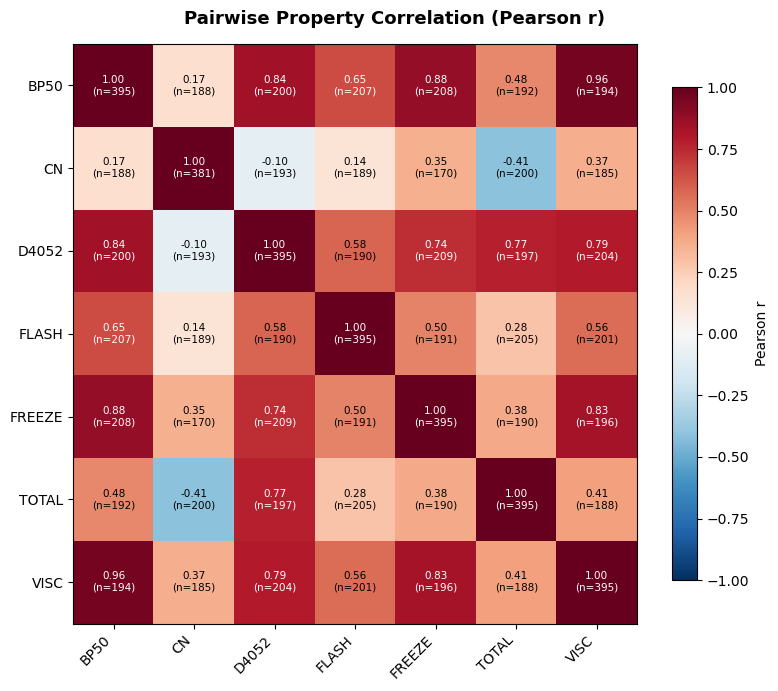

03_property_correlation.png saved ✓

Strong correlations (|r| > 0.4):
  BP50 ↔ D4052: r = 0.841
  BP50 ↔ FLASH: r = 0.653
  BP50 ↔ FREEZE: r = 0.877
  BP50 ↔ TOTAL: r = 0.482
  BP50 ↔ VISC: r = 0.960
  CN ↔ TOTAL: r = -0.414
  D4052 ↔ FLASH: r = 0.583
  D4052 ↔ FREEZE: r = 0.737
  D4052 ↔ TOTAL: r = 0.774
  D4052 ↔ VISC: r = 0.792
  FLASH ↔ FREEZE: r = 0.498
  FLASH ↔ VISC: r = 0.561
  FREEZE ↔ VISC: r = 0.833
  TOTAL ↔ VISC: r = 0.409


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4  —  Pairwise Property Correlation Heatmap              ║
# ╚══════════════════════════════════════════════════════════════════╝
corr = Y_raw[prop_names].corr(method='pearson')
n_p  = len(prop_names)

fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Pairwise Property Correlation (Pearson r)", fontsize=13, fontweight='bold')

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.85)
ax.set_xticks(range(n_p)); ax.set_yticks(range(n_p))
ax.set_xticklabels(prop_names, rotation=45, ha='right')
ax.set_yticklabels(prop_names)

for i in range(n_p):
    for j in range(n_p):
        val  = corr.values[i, j]
        n_ij = Y_raw[[prop_names[i], prop_names[j]]].dropna().shape[0]
        ax.text(j, i, f'{val:.2f}\n(n={n_ij})', ha='center', va='center',
                fontsize=7.5, color='white' if abs(val) > 0.6 else 'black')

plt.tight_layout()
plt.savefig("reports/figures/03_property_correlation.png", **SAVE_KW)
plt.show(); print("03_property_correlation.png saved ✓")

print("\nStrong correlations (|r| > 0.4):")
for i in range(n_p):
    for j in range(i+1, n_p):
        r = corr.values[i, j]
        if abs(r) > 0.4:
            print(f"  {prop_names[i]} ↔ {prop_names[j]}: r = {r:.3f}")

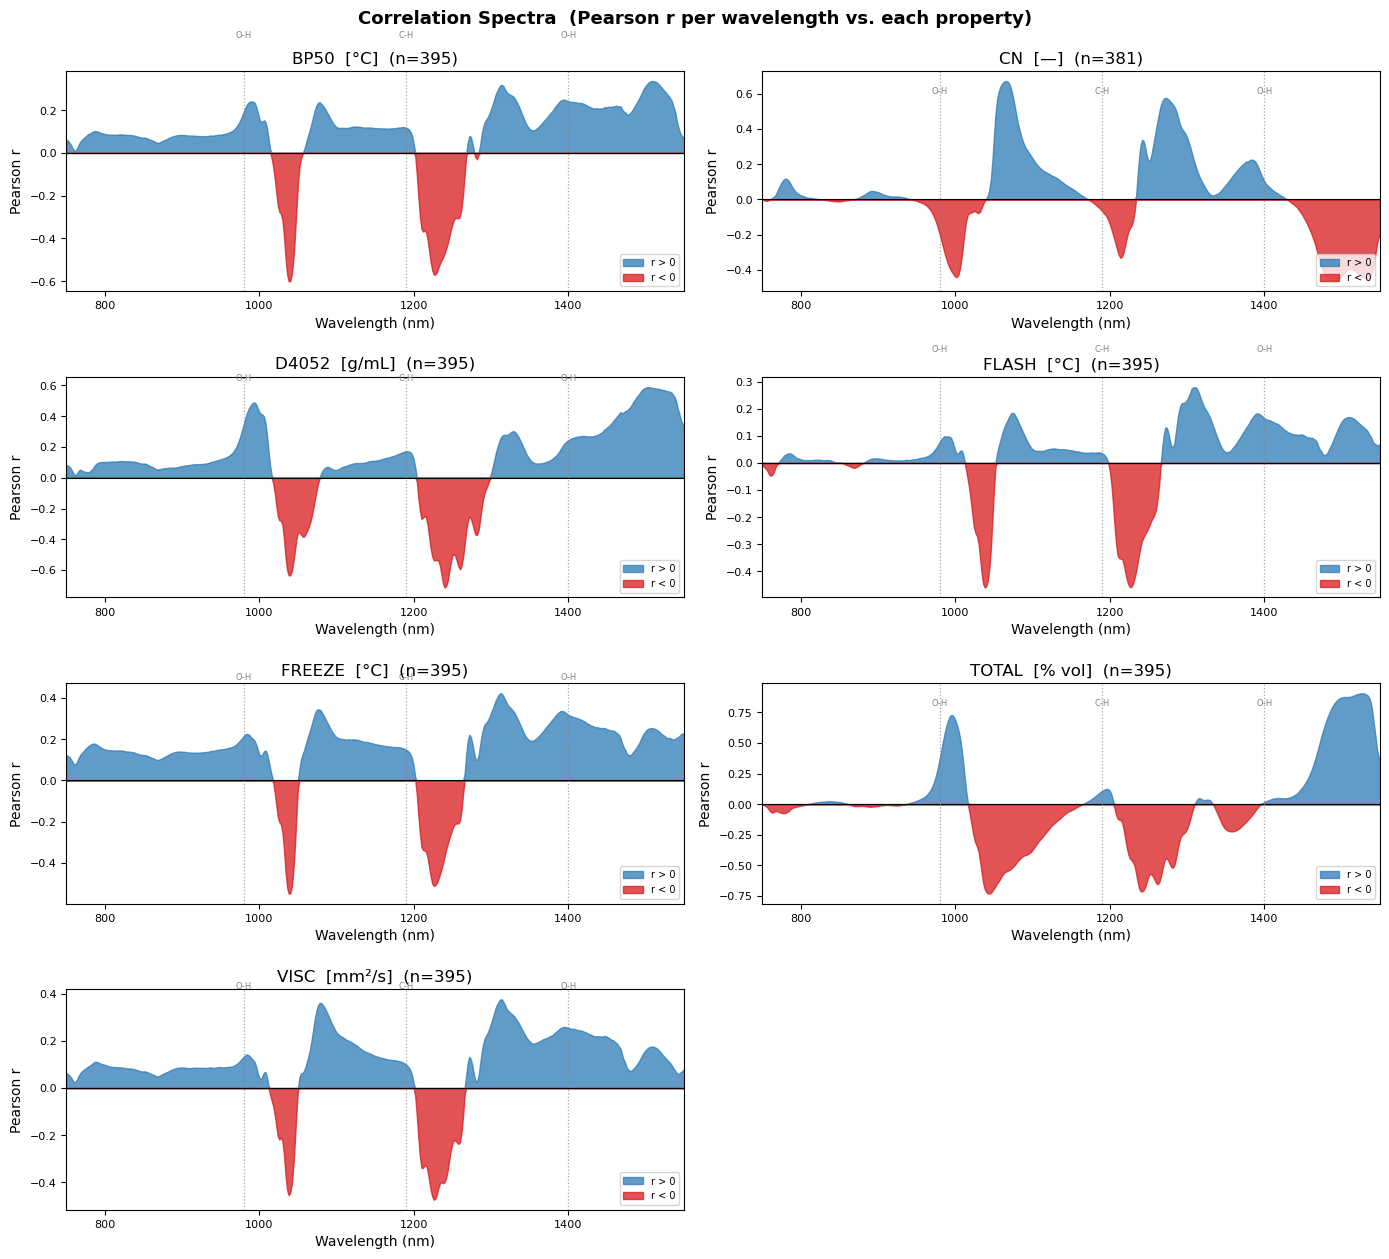

04_correlation_spectra.png saved ✓


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5  —  Correlation Spectra                                 ║
# ╚══════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
fig.suptitle("Correlation Spectra  (Pearson r per wavelength vs. each property)",
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for idx, prop in enumerate(prop_names):
    ax      = axes_flat[idx]
    r_vals  = corr_spectra[prop]
    n_valid = Y_raw[prop].notna().sum()

    ax.fill_between(wavelengths, np.clip(r_vals, 0, None),
                    alpha=0.75, color=PALETTE['main'], label='r > 0')
    ax.fill_between(wavelengths, np.clip(r_vals, None, 0),
                    alpha=0.75, color=PALETTE['warn'], label='r < 0')
    ax.axhline(0, color='k', lw=0.8)

    r_max = max(abs(r_vals.max()), abs(r_vals.min()))
    for band, label in NIR_BANDS:
        ax.axvline(band, color='gray', ls=':', lw=0.9, alpha=0.7)
        ax.text(band, r_max * 0.95, label, fontsize=6, color='gray', va='top', ha='center')

    ax.set(title=f'{prop}  [{PROP_UNITS.get(prop,"")}]  (n={n_valid})',
           xlabel='Wavelength (nm)', ylabel='Pearson r',
           xlim=(wavelengths[0], wavelengths[-1]))
    ax.legend(fontsize=7, loc='lower right')
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

for idx in range(len(prop_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig("reports/figures/04_correlation_spectra.png", **SAVE_KW)
plt.show(); print("04_correlation_spectra.png saved ✓")

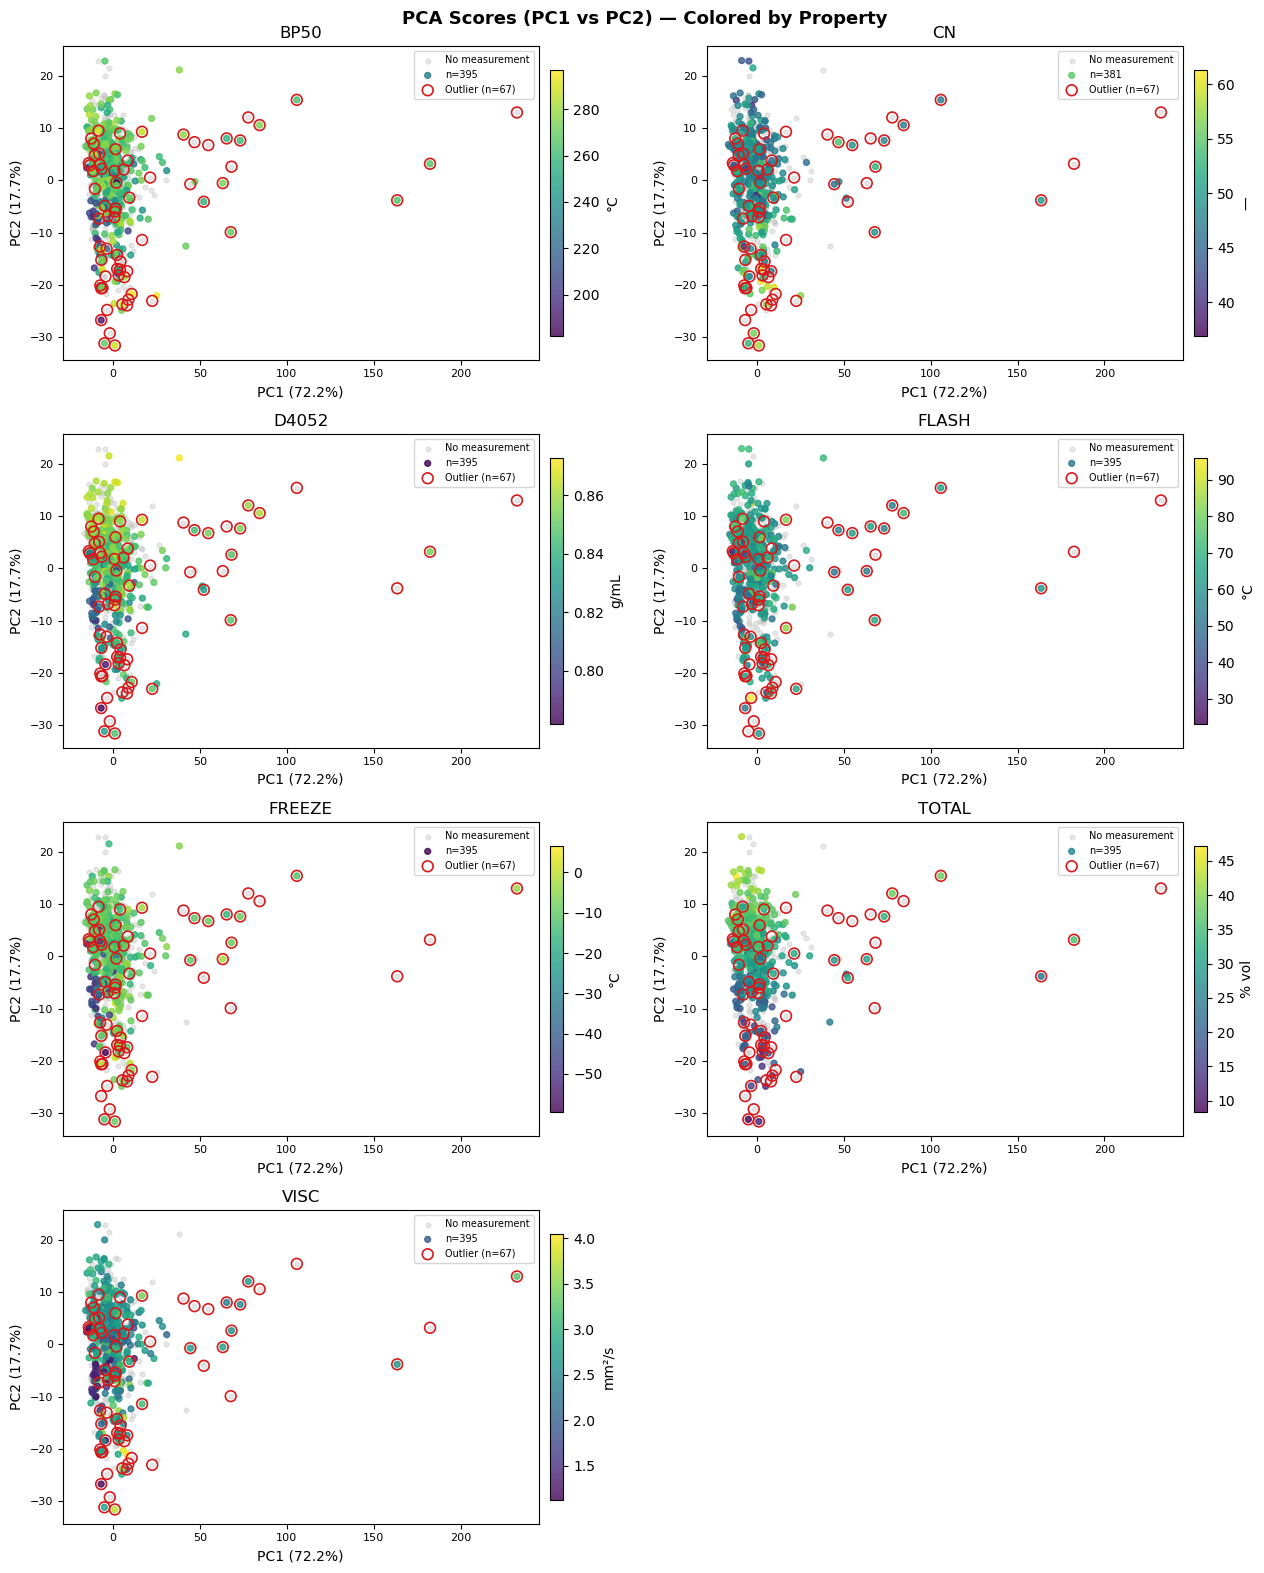

05_pca_scores.png saved ✓


In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6  —  PCA Scores Colored by Property                     ║
# ╚══════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4))
fig.suptitle("PCA Scores (PC1 vs PC2) — Colored by Property",
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for idx, prop in enumerate(prop_names):
    ax    = axes_flat[idx]
    valid = Y_raw[prop].notna().values
    vals  = Y_raw[prop].values

    ax.scatter(T[~valid, 0], T[~valid, 1],
               c=PALETTE['neutral'], s=12, alpha=0.35,
               label='No measurement', rasterized=True, zorder=1)
    sc = ax.scatter(T[valid, 0], T[valid, 1],
                    c=vals[valid], cmap='viridis', s=18, alpha=0.8,
                    zorder=2, label=f'n={valid.sum()}', rasterized=True)
    ax.scatter(T[outliers, 0], T[outliers, 1],
               facecolors='none', edgecolors=PALETTE['warn'],
               s=60, lw=1.2, zorder=3, label=f'Outlier (n={len(outliers)})')

    plt.colorbar(sc, ax=ax, label=PROP_UNITS.get(prop, ''), pad=0.02, shrink=0.85)
    ax.set(title=prop,
           xlabel=f'PC1 ({exp_var[0]:.1f}%)',
           ylabel=f'PC2 ({exp_var[1]:.1f}%)')
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc='upper right')

for idx in range(len(prop_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig("reports/figures/05_pca_scores.png", **SAVE_KW)
plt.show(); print("05_pca_scores.png saved ✓")

In [9]:
# ── Cell A: Spectral Preprocessing Functions & Candidate Arrays ──────────────
#
# Note: scipy.signal.savgol_filter and numpy.linalg.pinv both crash in this
# environment due to a numpy 2.x / LAPACK DLL conflict (Windows error 0xc06d007f).
# The SG first derivative for poly=2 is therefore implemented analytically:
#   for a symmetric window [-h, ..., h] and quadratic polynomial, the
#   first-derivative coefficients reduce to c_j = j / sum(j^2)  (no SVD needed).
#   This is mathematically identical to the scipy implementation for poly=2, deriv=1.

# ── 1. Preprocessing transforms ──────────────────────────────────────────────

def snv(X):
    """
    Standard Normal Variate (Barnes et al., 1989).
    Row-wise: subtract row mean, divide by row std.
    Removes multiplicative scatter and pathlength variation.
    """
    mu  = X.mean(axis=1, keepdims=True)
    sig = X.std(axis=1, keepdims=True)
    return (X - mu) / sig


def sg_derivative(X, window=11):
    """
    Savitzky-Golay first derivative, polynomial order 2 (Savitzky & Golay, 1964).
    Analytic coefficients: c_j = j / sum(j^2) for j in [-half, ..., half].
    Equivalent to scipy.signal.savgol_filter(X, window, 2, deriv=1, axis=1).
    Default window=11 is standard for 750-1550 nm NIR (2 nm spacing).
    Applied row-wise via 1D convolution; mode='same' preserves array length.
    """
    half   = window // 2
    j      = np.arange(-half, half + 1, dtype=float)
    coeffs = j / np.sum(j ** 2)          # shape (window,) — no linalg required
    return np.apply_along_axis(
        lambda row: np.convolve(row, coeffs[::-1], mode='same'),
        axis=1, arr=X
    )


def snv_sg(X, window=11):
    """
    SNV followed by SG first derivative — most common order in NIR literature.
    SNV corrects multiplicative scatter first; SG sharpens spectral features.
    """
    return sg_derivative(snv(X), window=window)


def mean_center(X):
    """Column-wise mean centering (mandatory for PLS)."""
    return X - X.mean(axis=0, keepdims=True)


# ── 2. Produce the four candidate preprocessed arrays ────────────────────────
# All arrays are mean-centred so they can be passed directly into PLSRegression.

X_raw_mc  = mean_center(X)           # baseline: raw + mean center only
X_snv     = mean_center(snv(X))      # SNV + mean center
X_sg1     = mean_center(sg_derivative(X))   # SG 1st derivative + mean center
X_snv_sg1 = mean_center(snv_sg(X))  # SNV → SG 1st derivative + mean center

preproc_arrays = {
    "Raw (MC)":      X_raw_mc,
    "SNV":           X_snv,
    "SG 1st deriv":  X_sg1,
    "SNV + SG":      X_snv_sg1,
}

# ── 3. Summary ────────────────────────────────────────────────────────────────
print("Preprocessing candidates ready")
print(f"{'Name':<18} {'Shape':>12}  {'Mean':>10}  {'Std':>10}")
print("-" * 56)
for name, arr in preproc_arrays.items():
    print(f"{name:<18} {str(arr.shape):>12}  {arr.mean():>10.4f}  {arr.std():>10.4f}")

Preprocessing candidates ready
Name                      Shape        Mean         Std
--------------------------------------------------------
Raw (MC)             (784, 401)      0.0000      0.0169
SNV                  (784, 401)      0.0000      0.0634
SG 1st deriv         (784, 401)     -0.0000      0.0015
SNV + SG             (784, 401)     -0.0000      0.0065


  ✓  Raw (MC)
  ✓  SNV
  ✓  SG 1st deriv
  ✓  SNV + SG

CV complete.


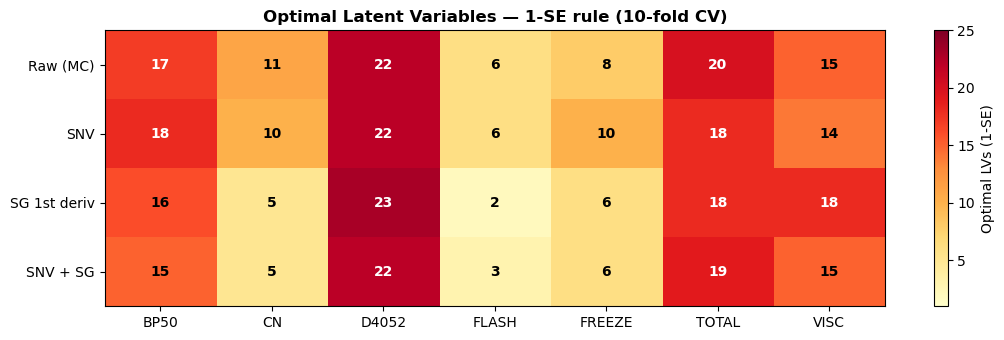

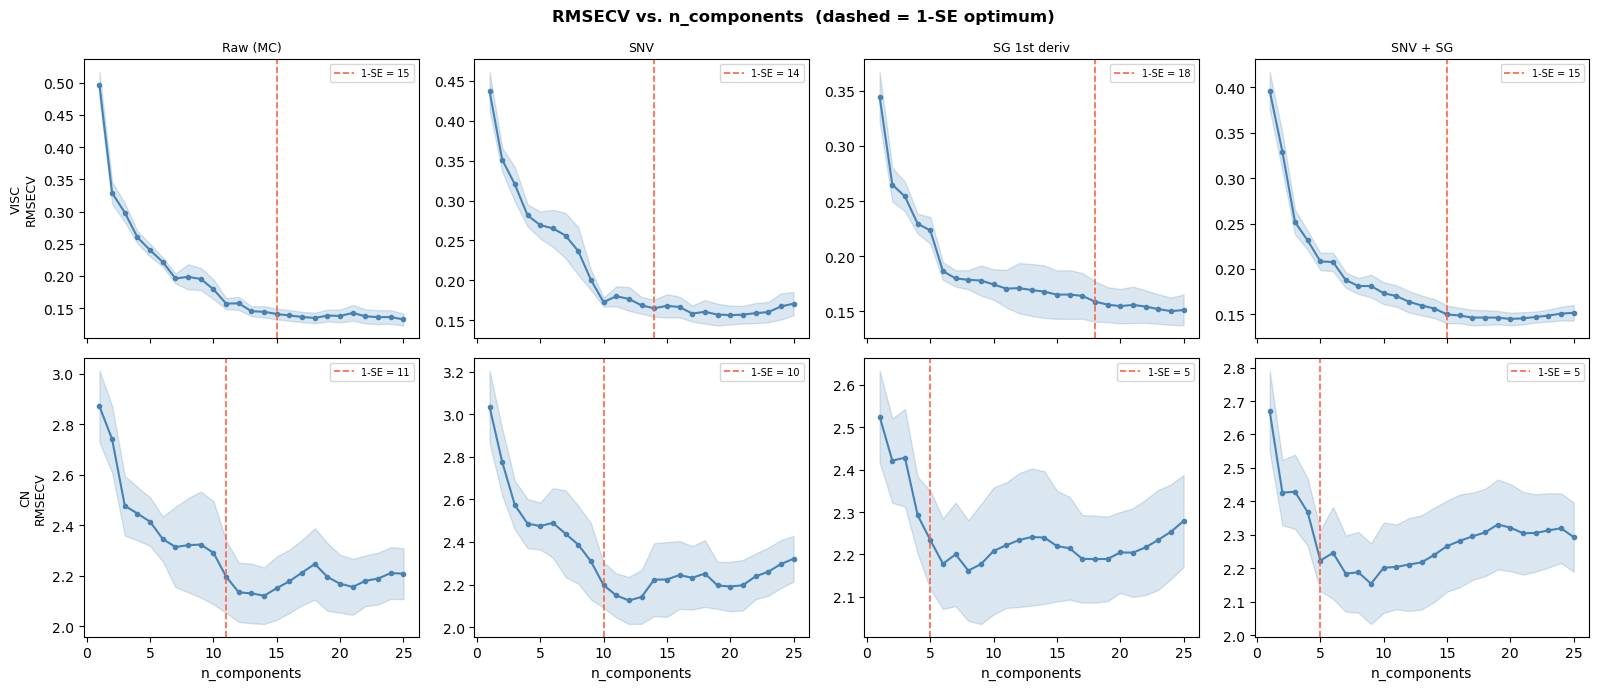

06_lv_selection.png saved ✓


In [10]:
# ── Cell B: PLS Cross-Validation — Optimal LV Selection ──────────────────────
#
# For each preprocessing candidate and property, 10-fold CV RMSECV curves
# are computed over n_components = 1…25. Both raw argmin and 1-SE rule
# are stored. Figures saved to reports/figures/06_lv_selection.png.

MAX_LV       = 25
N_FOLDS      = 10
INSPECT_PROPS = ["VISC", "CN"]

def _rmsecv_curve(X_m, y_m, max_lv, kf_m):
    """Per-LV mean RMSECV and its standard error across folds."""
    rmsecv    = np.zeros(max_lv)
    rmsecv_se = np.zeros(max_lv)
    for lv in range(1, max_lv + 1):
        fold_err = []
        for tr, te in kf_m.split(X_m):
            pls = PLSRegression(n_components=lv, max_iter=500)
            pls.fit(X_m[tr], y_m[tr])
            y_hat = pls.predict(X_m[te]).ravel()
            fold_err.append(np.sqrt(mean_squared_error(y_m[te], y_hat)))
        rmsecv[lv - 1]    = np.mean(fold_err)
        rmsecv_se[lv - 1] = np.std(fold_err, ddof=1) / np.sqrt(len(fold_err))
    return rmsecv, rmsecv_se

def _opt_lv_1se(rmsecv, rmsecv_se):
    """Smallest LV whose RMSECV is within 1 SE of the global minimum."""
    best = int(np.argmin(rmsecv))
    thr  = rmsecv[best] + rmsecv_se[best]
    return int(np.where(rmsecv <= thr)[0][0]) + 1

# ── 1. CV loop ────────────────────────────────────────────────────────────────
cv_results = {}
for prep_name, X_prep in preproc_arrays.items():
    cv_results[prep_name] = {}
    for i, prop in enumerate(prop_names):
        y_vec = Y[:, i]
        mask  = np.isfinite(y_vec)
        X_m, y_m = X_prep[mask], y_vec[mask]
        n_m = int(mask.sum())
        folds = min(N_FOLDS, n_m)
        kf_m  = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)

        rmsecv, rmsecv_se = _rmsecv_curve(X_m, y_m, MAX_LV, kf_m)
        opt_raw = int(np.argmin(rmsecv)) + 1
        opt_1se = _opt_lv_1se(rmsecv, rmsecv_se)
        cv_results[prep_name][prop] = {
            "rmsecv":    rmsecv,
            "rmsecv_se": rmsecv_se,
            "opt_lv":    opt_raw,
            "opt_lv_1se": opt_1se,
            "n":         n_m,
        }
    print(f"  ✓  {prep_name}")

print("\nCV complete.")

# ── 2. Heatmap — optimal LV (1-SE rule) ──────────────────────────────────────
prep_labels = list(preproc_arrays.keys())
opt_lv_matrix = np.array([
    [cv_results[p][prop]["opt_lv_1se"] for prop in prop_names]
    for p in prep_labels
])

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(opt_lv_matrix, cmap="YlOrRd", aspect="auto", vmin=1, vmax=MAX_LV)
ax.set_xticks(range(len(prop_names)))
ax.set_xticklabels(prop_names, fontsize=10)
ax.set_yticks(range(len(prep_labels)))
ax.set_yticklabels(prep_labels, fontsize=10)
for i, row in enumerate(opt_lv_matrix):
    for j, val in enumerate(row):
        color = "white" if val > MAX_LV * 0.65 else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)
plt.colorbar(im, ax=ax, label="Optimal LVs (1-SE)")
ax.set_title("Optimal Latent Variables — 1-SE rule (10-fold CV)", fontweight="bold")
fig.tight_layout()
plt.savefig("reports/figures/06_lv_selection_heatmap.png", **SAVE_KW)

# ── 3. RMSECV curves for VISC and CN ─────────────────────────────────────────
lv_axis = np.arange(1, MAX_LV + 1)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
fig.suptitle("RMSECV vs. n_components  (dashed = 1-SE optimum)", fontweight="bold")

for row, prop in enumerate(INSPECT_PROPS):
    for col, prep_name in enumerate(prep_labels):
        ax   = axes[row, col]
        data = cv_results[prep_name][prop]
        ax.plot(lv_axis, data["rmsecv"], "o-", lw=1.5, ms=3, color="steelblue")
        ax.fill_between(lv_axis,
                        data["rmsecv"] - data["rmsecv_se"],
                        data["rmsecv"] + data["rmsecv_se"],
                        alpha=0.2, color="steelblue")
        ax.axvline(data["opt_lv_1se"], color="tomato", ls="--", lw=1.2,
                   label=f"1-SE = {data['opt_lv_1se']}")
        ax.set_title(f"{prep_name}" if row == 0 else "", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{prop}\nRMSECV", fontsize=9)
        if row == 1:
            ax.set_xlabel("n_components")
        ax.legend(fontsize=7)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

fig.tight_layout()
plt.savefig("reports/figures/06_lv_selection.png", **SAVE_KW)
plt.show()
print("06_lv_selection.png saved ✓")

Cohort: all  (n=784)
  ✓  Raw (MC)
  ✓  SNV
  ✓  SG 1st deriv
  ✓  SNV + SG
  ✓  SNV+SG ≤1450

Cohort: no_T2  (n=717)
  ✓  Raw (MC)
  ✓  SNV
  ✓  SG 1st deriv
  ✓  SNV + SG
  ✓  SNV+SG ≤1450

Cohort   Preproc           Mean LV  Mean RMSECV
------------------------------------------------
all      Raw (MC)             14.1       2.5743
all      SNV                  14.0       2.6094
all      SG 1st deriv         12.6       2.6366
all      SNV + SG             12.1       2.6725
all      SNV+SG ≤1450         10.4       2.6882
no_T2    Raw (MC)             13.6       2.3854
no_T2    SNV                  12.7       2.4482
no_T2    SG 1st deriv         11.3       2.4373
no_T2    SNV + SG             12.1       2.4056
no_T2    SNV+SG ≤1450         10.7       2.4649


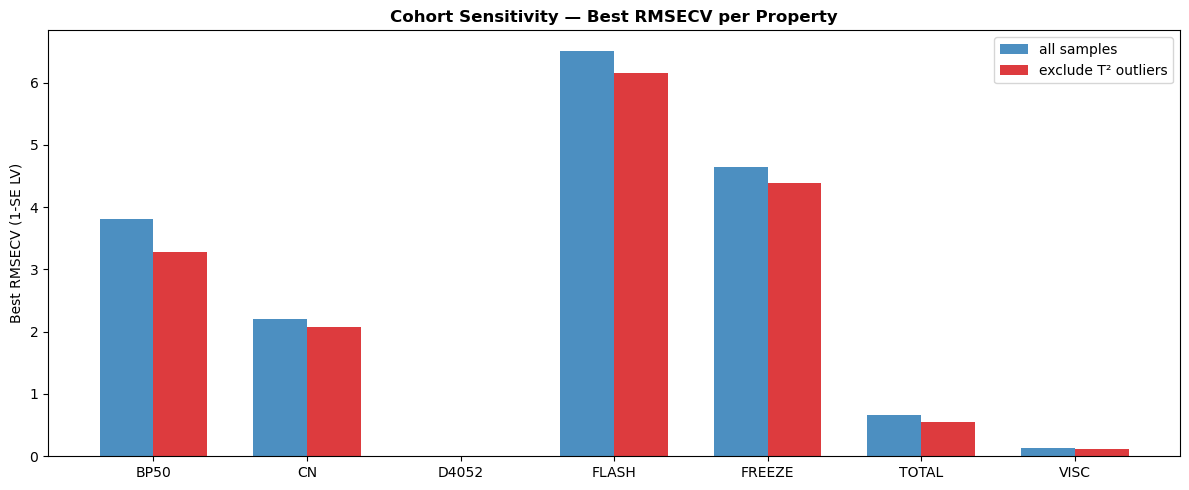

07_cohort_comparison.png saved ✓


In [11]:
# ── Cell C: Cohort Sensitivity + Expanded Preprocessing Grid ─────────────────
#
# Compares two sample policies (all vs exclude T² outliers) across 5
# preprocessing methods including SNV+SG truncated at 1450 nm.

WL_CUTOFF = 1450
wl_mask_1450 = wavelengths <= WL_CUTOFF

cohorts = {
    "all":   np.ones(len(X), dtype=bool),
    "no_T2": ~np.isin(np.arange(len(X)), outliers),
}

def build_preproc_arrays(X_sub):
    """Build 5 preprocessing candidates from a spectral subset."""
    X_trunc = X_sub[:, wl_mask_1450]
    return {
        "Raw (MC)":      mean_center(X_sub),
        "SNV":           mean_center(snv(X_sub)),
        "SG 1st deriv":  mean_center(sg_derivative(X_sub)),
        "SNV + SG":      mean_center(snv_sg(X_sub)),
        "SNV+SG ≤1450":  mean_center(snv_sg(X_trunc)),
    }

# ── 1. Dual-cohort CV sweep ───────────────────────────────────────────────────
cohort_cv = {}   # cohort_cv[cohort][preproc][prop] = dict
for cname, cmask in cohorts.items():
    print(f"Cohort: {cname}  (n={cmask.sum()})")
    X_c = X[cmask]
    Y_c = Y[cmask]
    prep_dict = build_preproc_arrays(X_c)
    cohort_cv[cname] = {}
    for prep_name, X_prep in prep_dict.items():
        cohort_cv[cname][prep_name] = {}
        for i, prop in enumerate(prop_names):
            y_vec = Y_c[:, i]
            mask  = np.isfinite(y_vec)
            X_m, y_m = X_prep[mask], y_vec[mask]
            n_m = int(mask.sum())
            folds = min(N_FOLDS, n_m)
            kf_m  = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
            rmsecv, rmsecv_se = _rmsecv_curve(X_m, y_m, MAX_LV, kf_m)
            opt_1se = _opt_lv_1se(rmsecv, rmsecv_se)
            cohort_cv[cname][prep_name][prop] = {
                "rmsecv":     rmsecv,
                "rmsecv_se":  rmsecv_se,
                "opt_lv_1se": opt_1se,
                "rmsecv_min": float(rmsecv[opt_1se - 1]),
                "n":          n_m,
            }
        print(f"  ✓  {prep_name}")
    print()

# ── 2. Summary table ──────────────────────────────────────────────────────────
prep_labels_5 = list(build_preproc_arrays(X).keys())
print(f"{'Cohort':<8} {'Preproc':<16} {'Mean LV':>8} {'Mean RMSECV':>12}")
print("-" * 48)
for cname in cohorts:
    for prep in prep_labels_5:
        lvs  = [cohort_cv[cname][prep][p]["opt_lv_1se"] for p in prop_names]
        rms  = [cohort_cv[cname][prep][p]["rmsecv_min"] for p in prop_names]
        print(f"{cname:<8} {prep:<16} {np.mean(lvs):>8.1f} {np.mean(rms):>12.4f}")

# ── 3. Bar chart — best RMSECV per property: all vs no_T2 ─────────────────────
# For each property, pick the best preprocessing within each cohort.
best_per_cohort = {}
for cname in cohorts:
    best_per_cohort[cname] = {}
    for prop in prop_names:
        best_prep, best_rms = None, np.inf
        for prep in prep_labels_5:
            rms = cohort_cv[cname][prep][prop]["rmsecv_min"]
            if rms < best_rms:
                best_rms, best_prep = rms, prep
        best_per_cohort[cname][prop] = {"preproc": best_prep, "rmsecv": best_rms}

x = np.arange(len(prop_names))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, [best_per_cohort["all"][p]["rmsecv"] for p in prop_names],
       w, label="all samples", color=PALETTE["main"], alpha=0.85)
ax.bar(x + w/2, [best_per_cohort["no_T2"][p]["rmsecv"] for p in prop_names],
       w, label="exclude T² outliers", color=PALETTE["warn"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(prop_names)
ax.set_ylabel("Best RMSECV (1-SE LV)")
ax.set_title("Cohort Sensitivity — Best RMSECV per Property", fontweight="bold")
ax.legend()
fig.tight_layout()
plt.savefig("reports/figures/07_cohort_comparison.png", **SAVE_KW)
plt.show()
print("07_cohort_comparison.png saved ✓")

Property Preproc            LV Cohort     RMSECV     n
-------------------------------------------------------
BP50     SG 1st deriv       13 no_T2      3.5404   363
CN       Raw (MC)            7 no_T2      2.0704   345
D4052    Raw (MC)           23 no_T2      0.0009   356
FLASH    Raw (MC)            6 all        6.5127   395
FREEZE   SNV                10 all        4.6401   395
TOTAL    SNV                15 no_T2      0.5811   360
VISC     Raw (MC)           16 no_T2      0.1217   362


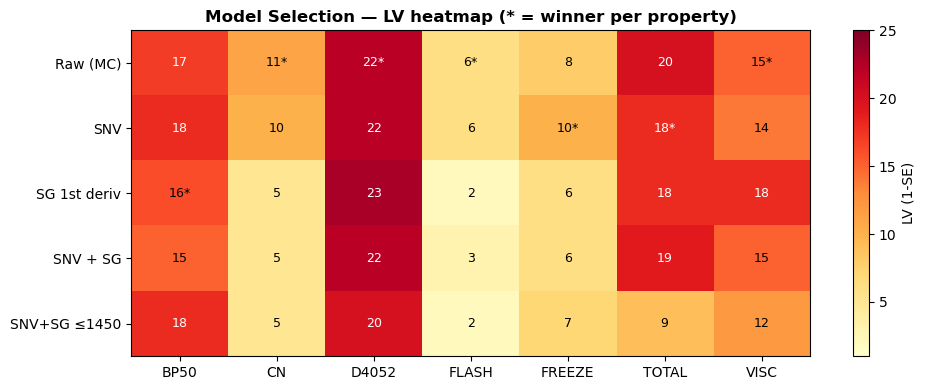

08_model_selection.png saved ✓


In [12]:
# ── Cell D: Per-Property Winner Selection ─────────────────────────────────────
#
# Locks preprocessing + LV + cohort for each property into model_config.

IMPROVEMENT_THRESH = 0.05   # 5% RMSECV improvement to prefer no_T2 cohort

model_config = {}
for prop in prop_names:
    # Step 1: best preprocessing within "all" cohort
    best_prep_all, best_rms_all = None, np.inf
    for prep in prep_labels_5:
        rms = cohort_cv["all"][prep][prop]["rmsecv_min"]
        if rms < best_rms_all:
            best_rms_all, best_prep_all = rms, prep

    # Step 2: same preprocessing in no_T2 cohort
    rms_no_t2 = cohort_cv["no_T2"][best_prep_all][prop]["rmsecv_min"]
    rel_improve = (best_rms_all - rms_no_t2) / best_rms_all

    if rel_improve >= IMPROVEMENT_THRESH:
        cohort_choice = "no_T2"
        final_rms     = rms_no_t2
        final_lv      = cohort_cv["no_T2"][best_prep_all][prop]["opt_lv_1se"]
        final_n       = cohort_cv["no_T2"][best_prep_all][prop]["n"]
    else:
        cohort_choice = "all"
        final_rms     = best_rms_all
        final_lv      = cohort_cv["all"][best_prep_all][prop]["opt_lv_1se"]
        final_n       = cohort_cv["all"][best_prep_all][prop]["n"]

    model_config[prop] = {
        "preproc":      best_prep_all,
        "n_components": final_lv,
        "cohort":       cohort_choice,
        "rmsecv":       final_rms,
        "n_cal":        final_n,
    }

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Property':<8} {'Preproc':<16} {'LV':>4} {'Cohort':<8} {'RMSECV':>8} {'n':>5}")
print("-" * 55)
for prop in prop_names:
    c = model_config[prop]
    print(f"{prop:<8} {c['preproc']:<16} {c['n_components']:>4} {c['cohort']:<8} {c['rmsecv']:>8.4f} {c['n_cal']:>5}")

# ── Heatmap: winner LV per property × preprocessing (all cohort) ──────────────
lv_matrix = np.array([
    [cohort_cv["all"][prep][prop]["opt_lv_1se"] for prop in prop_names]
    for prep in prep_labels_5
])
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(lv_matrix, cmap="YlOrRd", aspect="auto", vmin=1, vmax=MAX_LV)
ax.set_xticks(range(len(prop_names)))
ax.set_xticklabels(prop_names)
ax.set_yticks(range(len(prep_labels_5)))
ax.set_yticklabels(prep_labels_5)
for i, row in enumerate(lv_matrix):
    for j, val in enumerate(row):
        star = "*" if model_config[prop_names[j]]["preproc"] == prep_labels_5[i] else ""
        ax.text(j, i, f"{val}{star}", ha="center", va="center", fontsize=9,
                color="white" if val > MAX_LV * 0.65 else "black")
plt.colorbar(im, ax=ax, label="LV (1-SE)")
ax.set_title("Model Selection — LV heatmap (* = winner per property)", fontweight="bold")
fig.tight_layout()
plt.savefig("reports/figures/08_model_selection.png", **SAVE_KW)
plt.show()
print("08_model_selection.png saved ✓")

Property  R²_test    RMSEP     Bias    RPD  n_test
--------------------------------------------------
BP50        0.950   3.5274  -0.2983   4.52      73
CN          0.604   1.9539   0.2362   1.60      69
D4052       0.995   0.0010  -0.0001  14.86      72
FLASH       0.569   4.9544  -0.1283   1.53      79
FREEZE      0.809   4.8139  -0.4083   2.30      79
TOTAL       0.990   0.5987  -0.1206  10.21      72
VISC        0.918   0.1245   0.0023   3.52      73


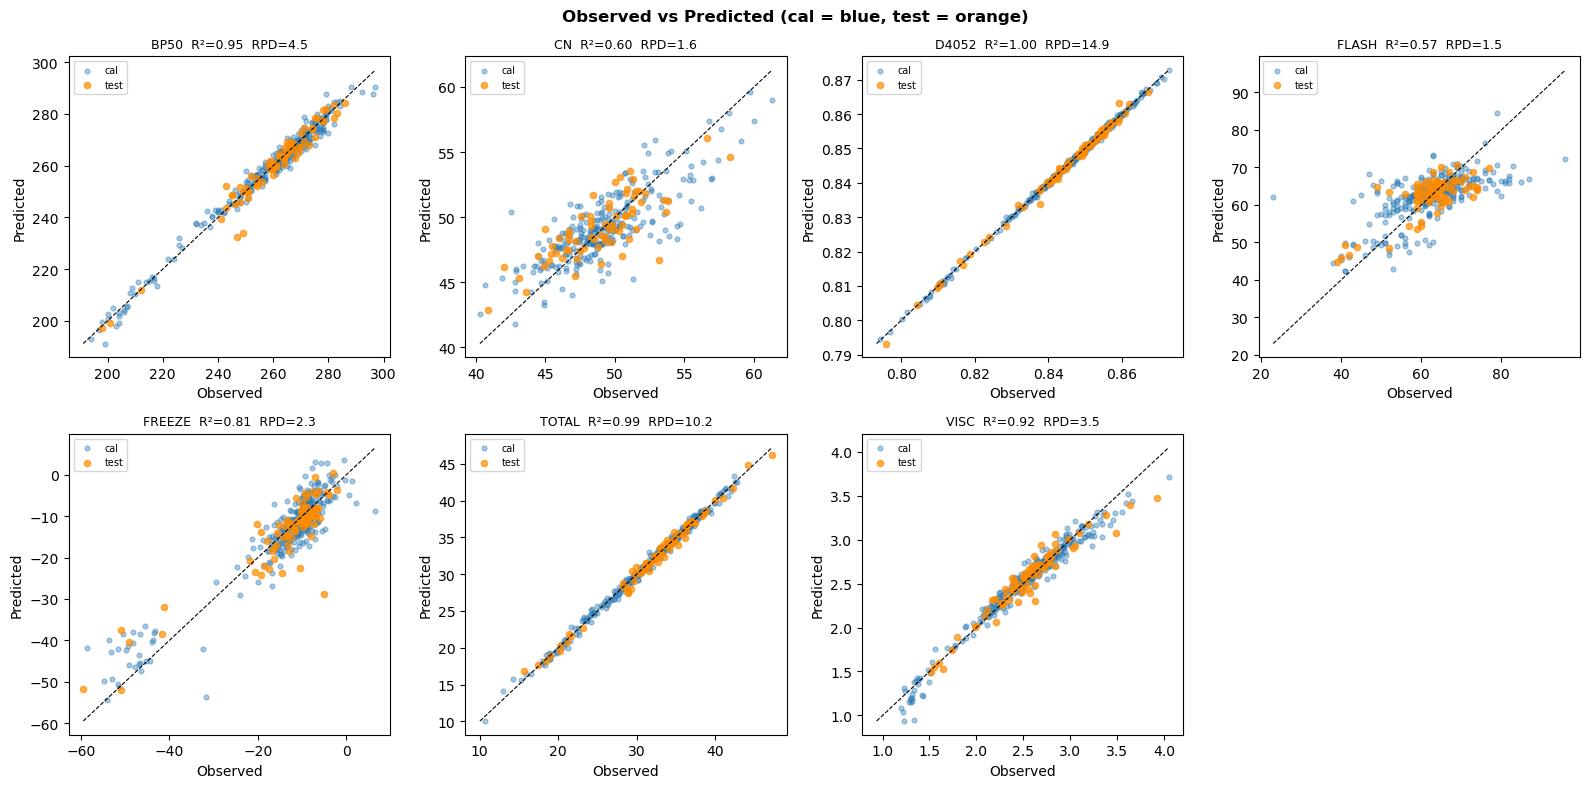

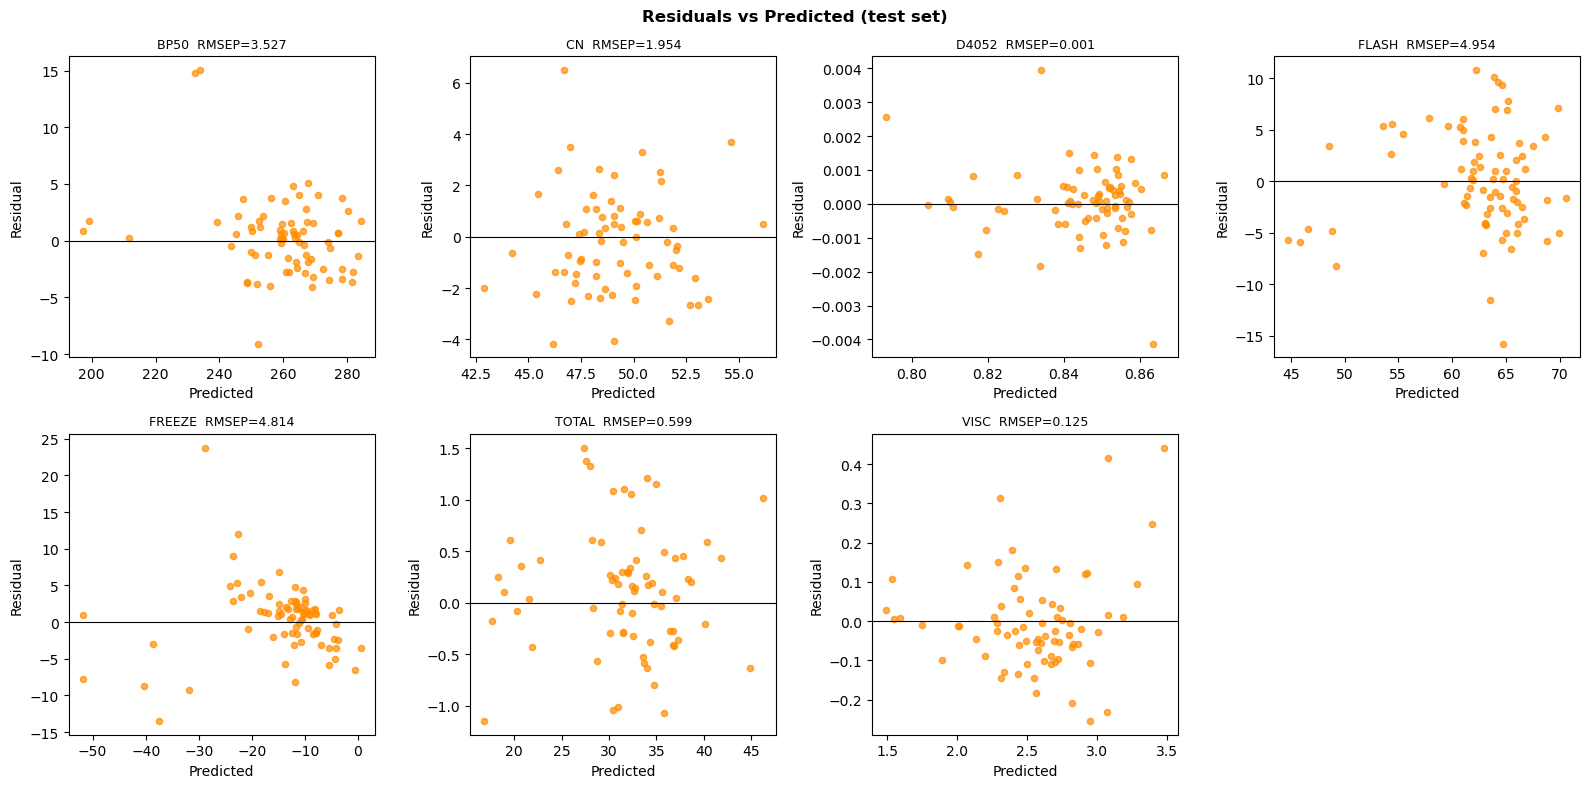

09_prediction_parity.png & 10_residuals.png saved ✓


In [13]:
# ── Cell E: Final Models + Held-Out Validation ────────────────────────────────
#
# 80/20 random split per property. Metrics: R², RMSEP, bias, RPD.

from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20
final_results = {}
fitted_models = {}

for prop in prop_names:
    cfg = model_config[prop]
    cmask = cohorts[cfg["cohort"]]
    i = prop_names.index(prop)
    y_all = Y[:, i]

    # Valid rows: cohort mask + finite y
    valid = cmask & np.isfinite(y_all)
    idx_valid = np.where(valid)[0]

    # Build preprocessed X for this property's winner
    X_sub = X[cmask]
    prep_dict = build_preproc_arrays(X_sub)
    X_prep = prep_dict[cfg["preproc"]]

    y_vec = y_all[valid]
    X_m   = X_prep[np.isfinite(y_all[cmask])]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_m, y_vec, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    pls = PLSRegression(n_components=cfg["n_components"], max_iter=500)
    pls.fit(X_tr, y_tr)
    y_tr_hat = pls.predict(X_tr).ravel()
    y_te_hat = pls.predict(X_te).ravel()

    rmsep = np.sqrt(mean_squared_error(y_te, y_te_hat))
    r2    = r2_score(y_te, y_te_hat)
    bias  = np.mean(y_te_hat - y_te)
    rpd   = np.std(y_te, ddof=1) / rmsep if rmsep > 0 else np.nan

    final_results[prop] = {
        "y_tr": y_tr, "y_te": y_te,
        "y_tr_hat": y_tr_hat, "y_te_hat": y_te_hat,
        "r2_test": r2, "rmsep": rmsep, "bias": bias, "rpd": rpd,
        "n_train": len(y_tr), "n_test": len(y_te),
    }
    fitted_models[prop] = pls

# ── Metrics table ─────────────────────────────────────────────────────────────
print(f"{'Property':<8} {'R²_test':>8} {'RMSEP':>8} {'Bias':>8} {'RPD':>6} {'n_test':>7}")
print("-" * 50)
for prop in prop_names:
    r = final_results[prop]
    print(f"{prop:<8} {r['r2_test']:>8.3f} {r['rmsep']:>8.4f} {r['bias']:>8.4f} {r['rpd']:>6.2f} {r['n_test']:>7}")

# ── Parity plots ──────────────────────────────────────────────────────────────
ncols_p = 4
nrows_p = (len(prop_names) + ncols_p - 1) // ncols_p
fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(4 * ncols_p, 4 * nrows_p))
fig.suptitle("Observed vs Predicted (cal = blue, test = orange)", fontweight="bold")
axes_flat = axes.flatten()

for idx, prop in enumerate(prop_names):
    ax = axes_flat[idx]
    r  = final_results[prop]
    lim = [min(r["y_tr"].min(), r["y_te"].min(), r["y_tr_hat"].min(), r["y_te_hat"].min()),
           max(r["y_tr"].max(), r["y_te"].max(), r["y_tr_hat"].max(), r["y_te_hat"].max())]
    ax.scatter(r["y_tr"], r["y_tr_hat"], s=12, alpha=0.4, color=PALETTE["main"],
               label="cal", rasterized=True)
    ax.scatter(r["y_te"], r["y_te_hat"], s=20, alpha=0.7, color="darkorange",
               label="test", rasterized=True)
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_title(f"{prop}  R²={r['r2_test']:.2f}  RPD={r['rpd']:.1f}", fontsize=9)
    ax.set_xlabel("Observed"); ax.set_ylabel("Predicted")
    ax.legend(fontsize=7)

for idx in range(len(prop_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)
fig.tight_layout()
plt.savefig("reports/figures/09_prediction_parity.png", **SAVE_KW)
plt.show()

# ── Residual plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(4 * ncols_p, 4 * nrows_p))
fig.suptitle("Residuals vs Predicted (test set)", fontweight="bold")
axes_flat = axes.flatten()

for idx, prop in enumerate(prop_names):
    ax = axes_flat[idx]
    r  = final_results[prop]
    resid = r["y_te"] - r["y_te_hat"]
    ax.scatter(r["y_te_hat"], resid, s=20, alpha=0.7, color="darkorange", rasterized=True)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{prop}  RMSEP={r['rmsep']:.3f}", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Residual")

for idx in range(len(prop_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)
fig.tight_layout()
plt.savefig("reports/figures/10_residuals.png", **SAVE_KW)
plt.show()
print("09_prediction_parity.png & 10_residuals.png saved ✓")

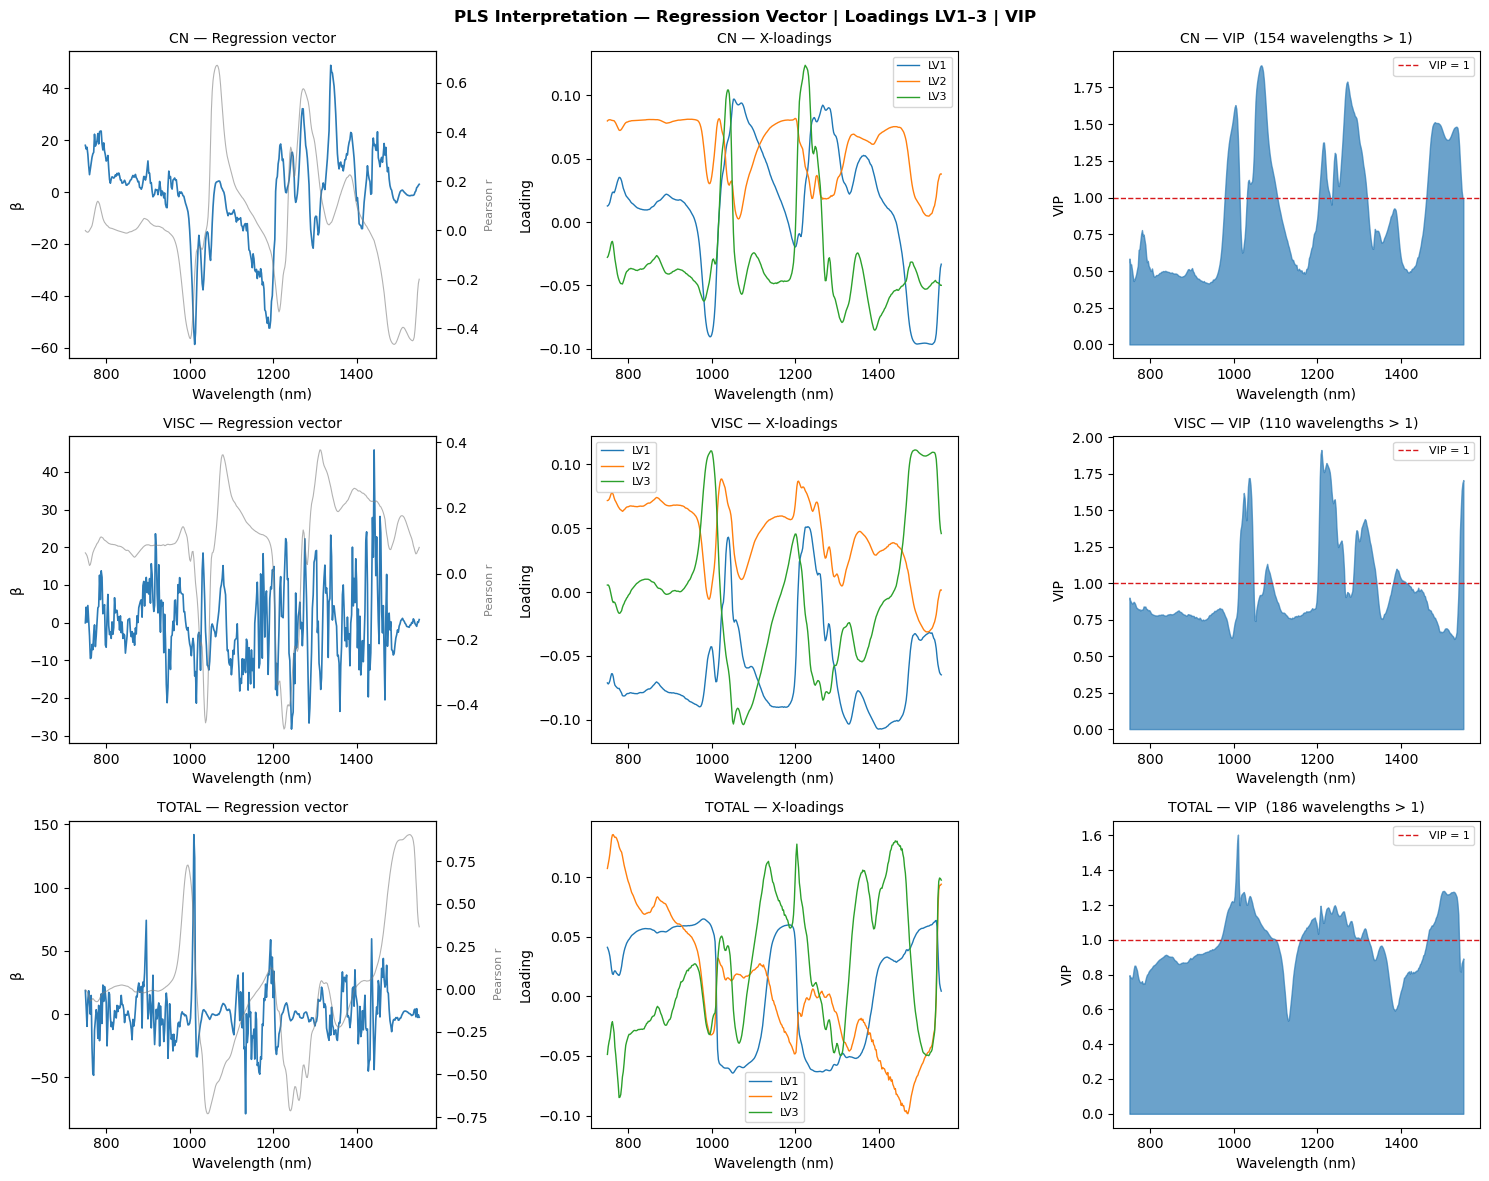

11_loadings_vip.png saved ✓


In [14]:
# ── Cell F: Model Interpretation — Loadings, Regression Vectors, VIP ──────────

INTERPRET_PROPS = ["CN", "VISC", "TOTAL"]

def compute_vip(pls):
    """VIP scores (Wold et al., 1993) from a fitted PLSRegression."""
    T = pls.x_scores_
    W = pls.x_weights_
    Q = pls.y_loadings_
    p, h = W.shape
    s = np.sum(T ** 2, axis=0) * Q.ravel() ** 2
    total_s = s.sum()
    vip = np.sqrt(p * np.sum(
        s[np.newaxis, :] * (W / np.linalg.norm(W, axis=0, keepdims=True)) ** 2,
        axis=1) / total_s)
    return vip

fig, axes = plt.subplots(len(INTERPRET_PROPS), 3,
                         figsize=(15, 4 * len(INTERPRET_PROPS)))
fig.suptitle("PLS Interpretation — Regression Vector | Loadings LV1–3 | VIP",
             fontweight="bold")

for row, prop in enumerate(INTERPRET_PROPS):
    pls = fitted_models[prop]
    cfg = model_config[prop]

    # Wavelength axis for this model
    if cfg["preproc"] == "SNV+SG ≤1450":
        wvl_plot = wavelengths[wl_mask_1450]
    else:
        wvl_plot = wavelengths

    # Regression vector (beta)
    beta = pls.coef_.ravel()

    # VIP
    vip = compute_vip(pls)

    # Loadings LV1–3
    n_show = min(3, cfg["n_components"])
    loadings = pls.x_loadings_[:, :n_show]

    # Panel 1: regression vector vs correlation spectrum
    ax = axes[row, 0]
    ax.plot(wvl_plot, beta, color=PALETTE["main"], lw=1.2, label="β (PLS)")
    if prop in corr_spectra:
        r_plot = corr_spectra[prop]
        if len(r_plot) == len(wvl_plot):
            ax2 = ax.twinx()
            ax2.plot(wvl_plot, r_plot, color="gray", lw=0.8, alpha=0.6, label="r (EDA)")
            ax2.set_ylabel("Pearson r", fontsize=8, color="gray")
    ax.set_title(f"{prop} — Regression vector", fontsize=10)
    ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("β")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

    # Panel 2: X-loadings LV1–3
    ax = axes[row, 1]
    for lv in range(n_show):
        ax.plot(wvl_plot, loadings[:, lv], lw=1.0, label=f"LV{lv+1}")
    ax.set_title(f"{prop} — X-loadings", fontsize=10)
    ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Loading")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

    # Panel 3: VIP
    ax = axes[row, 2]
    ax.fill_between(wvl_plot, vip, alpha=0.7, color=PALETTE["main"])
    ax.axhline(1.0, color=PALETTE["warn"], ls="--", lw=1.0, label="VIP = 1")
    n_vip = (vip > 1).sum()
    ax.set_title(f"{prop} — VIP  ({n_vip} wavelengths > 1)", fontsize=10)
    ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("VIP")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

fig.tight_layout()
plt.savefig("reports/figures/11_loadings_vip.png", **SAVE_KW)
plt.show()
print("11_loadings_vip.png saved ✓")

In [15]:
# ── Cell G: Summary Export ─────────────────────────────────────────────────────

import joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

rows = []
for prop in prop_names:
    cfg = model_config[prop]
    res = final_results[prop]
    rows.append({
        "Property":  prop,
        "n_cal":     cfg["n_cal"],
        "Preproc":   cfg["preproc"],
        "LVs":       cfg["n_components"],
        "Cohort":    cfg["cohort"],
        "RMSECV":    round(cfg["rmsecv"], 4),
        "R2_test":   round(res["r2_test"], 3),
        "RMSEP":     round(res["rmsep"], 4),
        "Bias":      round(res["bias"], 4),
        "RPD":       round(res["rpd"], 2),
        "n_test":    res["n_test"],
    })
    joblib.dump(fitted_models[prop], f"models/pls_{prop}.joblib")

summary_df = pd.DataFrame(rows)
summary_df.to_csv("reports/model_summary.csv", index=False)

print(summary_df.to_string(index=False))
print(f"\nreports/model_summary.csv saved ✓")
print(f"models/pls_*.joblib saved ✓  ({len(prop_names)} models)")

Property  n_cal      Preproc  LVs Cohort  RMSECV  R2_test  RMSEP    Bias   RPD  n_test
    BP50    363 SG 1st deriv   13  no_T2  3.5404    0.950 3.5274 -0.2983  4.52      73
      CN    345     Raw (MC)    7  no_T2  2.0704    0.604 1.9539  0.2362  1.60      69
   D4052    356     Raw (MC)   23  no_T2  0.0009    0.995 0.0010 -0.0001 14.86      72
   FLASH    395     Raw (MC)    6    all  6.5127    0.569 4.9544 -0.1283  1.53      79
  FREEZE    395          SNV   10    all  4.6401    0.809 4.8139 -0.4083  2.30      79
   TOTAL    360          SNV   15  no_T2  0.5811    0.990 0.5987 -0.1206 10.21      72
    VISC    362     Raw (MC)   16  no_T2  0.1217    0.918 0.1245  0.0023  3.52      73

reports/model_summary.csv saved ✓
models/pls_*.joblib saved ✓  (7 models)
